In [3]:
import glob
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import VarianceThreshold
import lightgbm as lgb

In [19]:
# Load Data

directory = r"C:\Users\victo\BGU project\Github\drug_discovery_project\Dataset"

csv_files = glob.glob(directory +'/*.csv')

df = pd.concat((pd.read_csv(f) for f in csv_files),ignore_index=True)
# Limit floats output to 3 decimal points
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

print(df.head())
print(df.describe())

   ID  MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0 NaN              5.726           5.726              0.187           0.187   
1 NaN              4.624           4.624              0.967           0.967   
2 NaN              5.834           5.834              0.237           0.237   
3 NaN              5.920           5.920              0.195           0.195   
4 NaN              5.834           5.834              0.237           0.237   

    qed   MolWt  HeavyAtomMolWt  ExactMolWt  NumValenceElectrons  ...  \
0 0.678 391.128         378.024     388.908                   96  ...   
1 0.666 298.229         284.117     297.006                   84  ...   
2 0.613 405.155         390.035     402.924                  102  ...   
3 0.476 484.051         469.939     480.835                  108  ...   
4 0.613 405.155         390.035     402.924                  102  ...   

   fr_sulfone  fr_term_acetylene  fr_tetrazole  fr_thiazole  fr_thiocyan  \
0         

In [20]:
# Data Preprocessing

# Outliers
# Removing all zero and positive values of the targe variable
df = df[df['RNA_28'] < 0]
print(df.describe())
print(df.shape)

         ID  MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  \
count 0.000         416007.000      416007.000         416007.000   
mean    NaN             11.889          11.889              0.158   
std     NaN              1.888           1.888              0.157   
min     NaN              2.139           2.139              0.000   
25%     NaN             11.873          11.873              0.050   
50%     NaN             12.236          12.236              0.117   
75%     NaN             12.708          12.708              0.215   
max     NaN             14.760          14.760              1.287   

       MinEStateIndex        qed      MolWt  HeavyAtomMolWt  ExactMolWt  \
count      416007.000 416007.000 416007.000      416007.000  416007.000   
mean           -1.156      0.736    354.326         333.754     353.841   
std             1.483      0.116     44.636          42.677      44.526   
min            -6.459      0.067    175.256         166.184     175.046   
25%

In [21]:
X = df.drop(columns=['RNA_28'])
y = df['RNA_28']

print('\nThe data size is: {}' .format(X.shape))
print('\nThe label size is: {}' .format(y.shape))

# Split to train and test
x_train, x_test, y_train, y_test = train_test_split(X, y,test_size=0.1,random_state=42)

print('\nThe train data size is: {}' .format(x_train.shape))
print('\nThe train label size is: {}' .format(y_train.shape))

print('\nThe test data size is: {}' .format(x_test.shape))
print('\nThe test label size is: {}' .format(y_test.shape))

# Save the ID columns for train and test
train_ID = x_train['ID']
test_ID = x_test['ID']

# Remove the ID columns
x_train = x_train.drop('ID',axis=1)
x_test = x_test.drop('ID',axis=1)


print('\nThe train data size after removing the ID feature is: {}' .format(x_train.shape))
print('\nThe test data size after removing the ID feature is: {}' .format(x_test.shape))


The data size is: (416007, 211)

The label size is: (416007,)

The train data size is: (374406, 211)

The train label size is: (374406,)

The test data size is: (41601, 211)

The test label size is: (41601,)

The train data size after removing the ID feature is: (374406, 210)

The test data size after removing the ID feature is: (41601, 210)


In [22]:
# Feature Selection

# Remove Low-Variance Features
selector = VarianceThreshold()
x_train_reduced = selector.fit_transform(x_train)

selected_columns = x_train.columns[selector.get_support()]
x_train_reduced = pd.DataFrame(x_train_reduced ,columns=selected_columns)
print("Remaining Features After Removing Low-variance Features:\n", x_train_reduced.head())
print(x_train_reduced.shape)

Remaining Features After Removing Low-variance Features:
    MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex   qed  \
0             13.069          13.069              0.170          -0.276 0.648   
1             11.890          11.890              0.030          -0.440 0.688   
2             12.235          12.235              0.358          -2.900 0.684   
3             12.139          12.139              0.359          -2.562 0.871   
4             11.926          11.926              0.235          -0.699 0.853   

    MolWt  HeavyAtomMolWt  ExactMolWt  NumValenceElectrons  MaxPartialCharge  \
0 379.501         353.293     379.173              142.000             0.315   
1 347.464         324.280     347.154              128.000             0.278   
2 385.436         364.268     385.127              142.000             0.315   
3 375.238         362.134     373.990              112.000             0.263   
4 319.386         302.250     319.099              116.

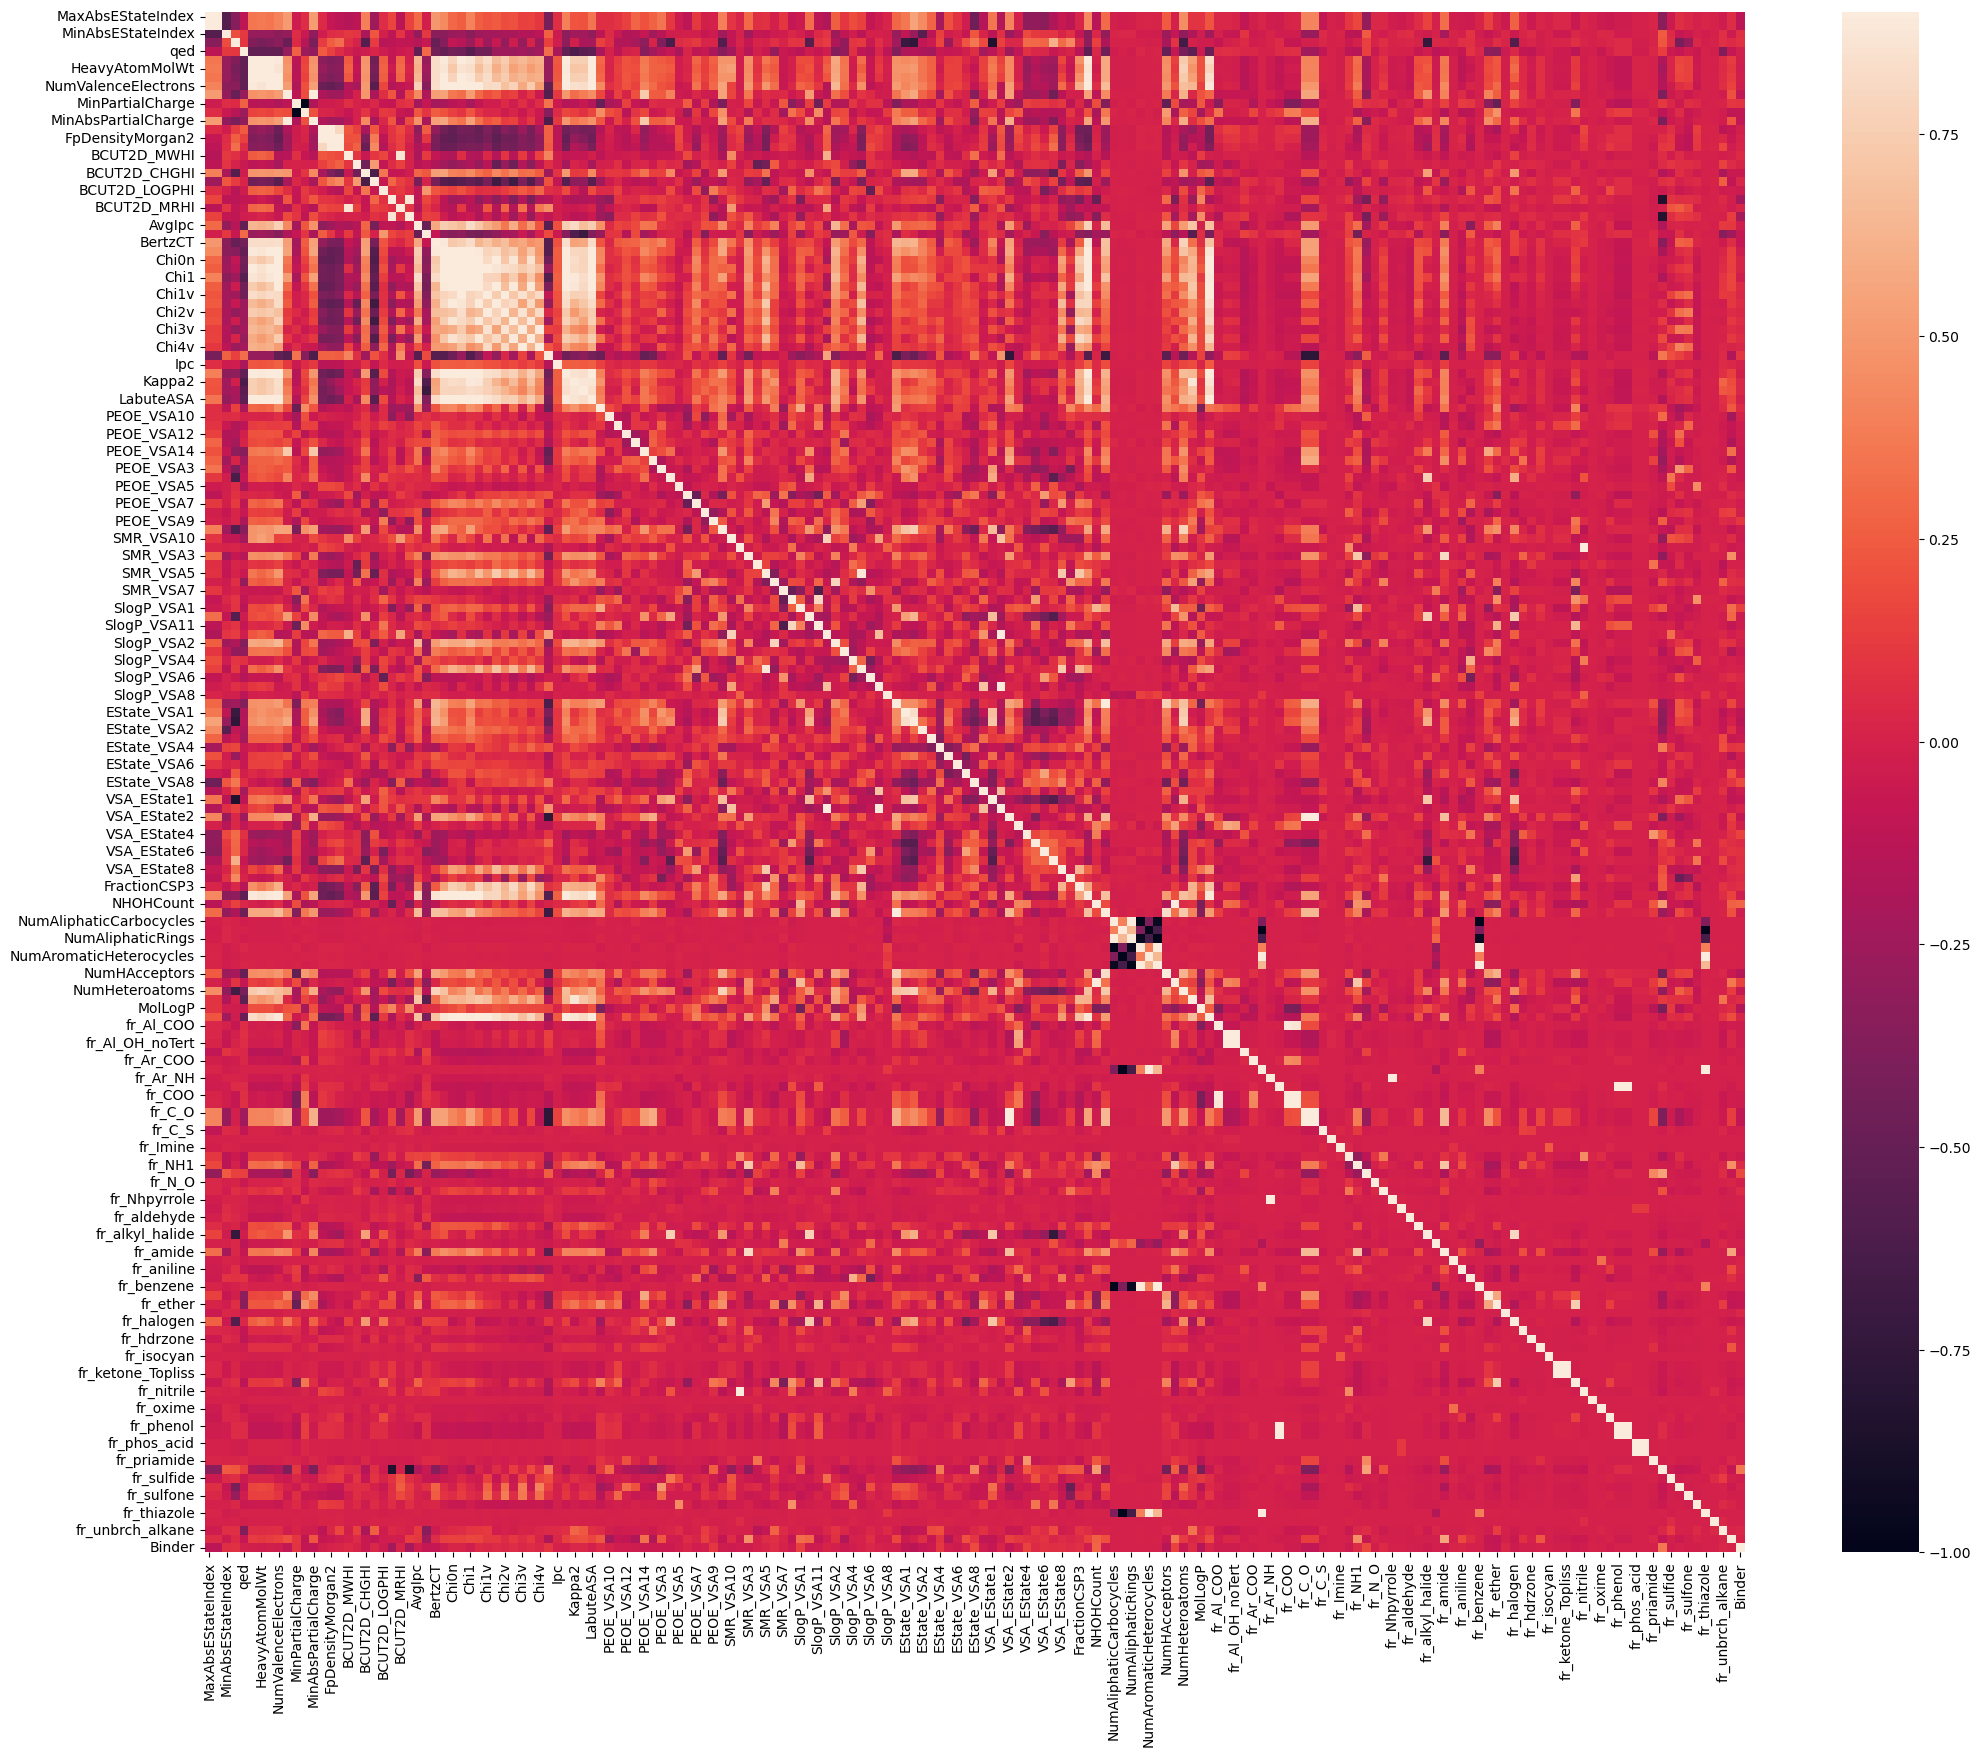

Remaining Features After Removing Redundant Features:
    MaxAbsEStateIndex  MinAbsEStateIndex  MinEStateIndex   qed   MolWt  \
0             13.069              0.170          -0.276 0.648 379.501   
1             11.890              0.030          -0.440 0.688 347.464   
2             12.235              0.358          -2.900 0.684 385.436   
3             12.139              0.359          -2.562 0.871 375.238   
4             11.926              0.235          -0.699 0.853 319.386   

   NumValenceElectrons  MaxPartialCharge  MinPartialCharge  \
0              142.000             0.315            -0.396   
1              128.000             0.278            -0.366   
2              142.000             0.315            -0.497   
3              112.000             0.263            -0.346   
4              116.000             0.426            -0.449   

   MaxAbsPartialCharge  FpDensityMorgan1  ...  fr_priamide  fr_quatN  \
0                0.396             1.269  ...        0.000   

In [23]:
#Correlation analysis

corrmat = x_train_reduced.corr()
plt.subplots(figsize=(25,20))
sns.heatmap(corrmat,vmax=0.9,square=True)
plt.show()

# Select upper triangle of the correlation matrix
upper_triangle = corrmat.where(np.triu(np.ones(corrmat.shape), k=1).astype(bool))

# Find features with high correlation (> 0.9)
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]

# Drop redundant features with correlation of > 0.9
x_train_red_corr = x_train_reduced.drop(columns=high_corr_features)
print("Remaining Features After Removing Redundant Features:\n", x_train_red_corr.head())

[LightGBM] [Info] Total Bins 17380
[LightGBM] [Info] Number of data points in the train set: 374406, number of used features: 135
[LightGBM] [Info] Start training from score -6.420011


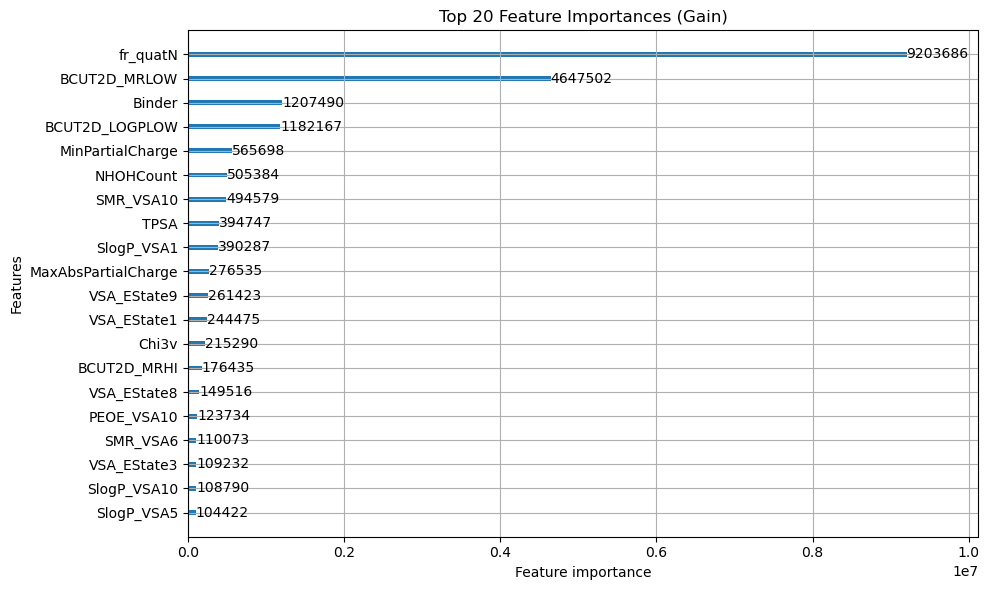

Feature Importance:
 MaxAbsEStateIndex   0.002
MinAbsEStateIndex   0.000
MinEStateIndex      0.003
qed                 0.000
MolWt               0.000
                     ... 
fr_term_acetylene   0.000
fr_thiocyan         0.000
fr_unbrch_alkane    0.002
fr_urea             0.001
Binder              0.053
Length: 141, dtype: float64

Selected Features:
 Index(['MinPartialCharge', 'MaxAbsPartialCharge', 'BCUT2D_LOGPLOW',
       'BCUT2D_MRLOW', 'SMR_VSA10', 'SlogP_VSA1', 'TPSA', 'VSA_EState1',
       'VSA_EState9', 'NHOHCount', 'fr_quatN', 'Binder'],
      dtype='object')

Shape Before: (374406, 141) → After: (374406, 12)


In [24]:
# Feature importance with LightGBM 
LGBM = lgb.LGBMRegressor(n_estimators=890, learning_rate=0.01,
                         max_depth=15, num_leaves=80,  
                         min_child_samples=30, min_split_gain=0.0,  
                         subsample=0.86, colsample_bytree=0.61,
                         random_state=42, force_col_wise=True)

LGBM.fit(x_train_red_corr, y_train)

# Get feature importance score
feature_importance = pd.Series(LGBM.booster_.feature_importance(importance_type='gain'), index=x_train_red_corr.columns)
gain_importance = feature_importance / feature_importance.sum()

# Select features with importance above the threshold
threshold = 0.01
selected_features_lgb = gain_importance[gain_importance> threshold].index
# Plot feature importance using Gain
lgb.plot_importance(LGBM, importance_type='gain', max_num_features=20, figsize=(10, 6),
                    title='Top 20 Feature Importances (Gain)', precision=0)
plt.tight_layout()
plt.show()

# Drop the low-importance features
x_train_reduced_lgb = x_train_red_corr[selected_features_lgb]
print('Feature Importance:\n', gain_importance)
print('\nSelected Features:\n', selected_features_lgb)
print('\nShape Before:', x_train_red_corr.shape, '→ After:', x_train_reduced_lgb.shape)
